In [1]:
# 07_experiments.ipynb - Експерименти з різними архітектурами

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import json
from datetime import datetime

from src.config import DATA_DIR, MODELS_DIR, FIGURES_DIR, RANDOM_SEED, MAX_SEQUENCE_LENGTH

%matplotlib inline

# Налаштування
plt.rcParams['figure.figsize'] = (12, 6)
(FIGURES_DIR / 'experiments').mkdir(parents=True, exist_ok=True)
(MODELS_DIR / 'experiments').mkdir(parents=True, exist_ok=True)

# Встановлюємо seed
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [2]:
print("Завантаження даних...")

# Завантажуємо дані
X_train = np.load(DATA_DIR / 'X_train.npy')
X_val = np.load(DATA_DIR / 'X_val.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')

y_train = np.load(DATA_DIR / 'y_train.npy')
y_val = np.load(DATA_DIR / 'y_val.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

# Завантажуємо інформацію
with open(DATA_DIR / 'preprocessing_info.json', 'r') as f:
    preprocessing_info = json.load(f)

vocab_size = preprocessing_info['vocab_size']

print(f"\nДані завантажено:")
print(f"  Train: {X_train.shape[0]:,} сесій")
print(f"  Val:   {X_val.shape[0]:,} сесій")
print(f"  Test:  {X_test.shape[0]:,} сесій")
print(f"  vocab_size: {vocab_size:,}")

# Обчислюємо class_weights для боротьби з дисбалансом класів
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n Class weights (для боротьби з дисбалансом):")
print(f"  Клас 0 (неякісні): {class_weights[0]:.4f}")
print(f"  Клас 1 (якісні):   {class_weights[1]:.4f}")

# Для швидкості експериментів беремо 20% даних
sample_size = int(len(X_train) * 0.2)
X_train_sample = X_train[:sample_size]
y_train_sample = y_train[:sample_size]

print(f"\n УВАГА: Для прискорення експериментів використовується {sample_size:,} сесій (20%)")
print(f"   Результати можуть відрізнятися від тренування на повних даних.")
print(f"   Для фінальної оцінки слід навчити найкращу модель на всіх даних.")

try:
    with open(MODELS_DIR / 'baseline' / 'baseline_results.json', 'r') as f:
        baseline_results = json.load(f)
    baseline_auc = baseline_results['test_metrics']['roc_auc']
    baseline_f1 = baseline_results['test_metrics']['f1_score']
    baseline_accuracy = baseline_results['test_metrics']['accuracy']
    print(f"\n Baseline (Random Forest) знайдено:")
    print(f"  Test Accuracy: {baseline_accuracy:.4f}")
    print(f"  Test F1-Score: {baseline_f1:.4f}")
    print(f"  Test ROC-AUC:  {baseline_auc:.4f}")
    baseline_loaded = True
except Exception as e:
    baseline_auc = None
    baseline_f1 = None
    baseline_accuracy = None
    baseline_loaded = False
    print(f"\  Baseline не знайдено: {e}")
    print("   Порівняння з baseline буде пропущено")

Завантаження даних...

Дані завантажено:
  Train: 6,474,810 сесій
  Val:   1,387,459 сесій
  Test:  1,387,460 сесій
  vocab_size: 52,740

 Class weights (для боротьби з дисбалансом):
  Клас 0 (неякісні): 0.5292
  Клас 1 (якісні):   9.0753

 УВАГА: Для прискорення експериментів використовується 1,294,962 сесій (20%)
   Результати можуть відрізнятися від тренування на повних даних.
   Для фінальної оцінки слід навчити найкращу модель на всіх даних.

 Baseline (Random Forest) знайдено:
  Test Accuracy: 0.7007
  Test F1-Score: 0.2014
  Test ROC-AUC:  0.7535


In [3]:
print("Налаштування функції тренування")

def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, 
                       class_weight_dict=None, epochs=20): 
    
    print(f"ТРЕНУВАННЯ: {model_name}")
    
    initial_learning_rate = 0.001
    decay_steps = 1000
    decay_rate = 0.9
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=decay_steps, decay_rate=decay_rate
    )
    
    # Компіляція
    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),  # ← динамічний LR
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, verbose=1, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)
    ]
    
    # Тренування з class_weight
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=128,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weight_dict,  
        verbose=1  
    )
    
    # Оцінка на тесті
    y_pred_proba = model.predict(X_test, batch_size=128, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    test_accuracy = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Найкращі значення
    best_val_auc = max(history.history['val_auc'])
    best_epoch = np.argmax(history.history['val_auc']) + 1
    
    print(f"\n РЕЗУЛЬТАТИ {model_name}:")
    print(f"  Краща епоха: {best_epoch}")
    print(f"  Val AUC: {best_val_auc:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")
    print(f"  Test F1-Score: {test_f1:.4f}")
    print(f"  Test ROC-AUC:  {test_auc:.4f}")
    
    return {
        'name': model_name,
        'best_epoch': best_epoch,
        'best_val_auc': best_val_auc,
        'test_accuracy': test_accuracy,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'history': history,
        'y_pred_proba': y_pred_proba,
        'y_pred': y_pred
    }

Налаштування функції тренування


In [4]:
print("Експеримент 1: БАЗОВА LSTM (контроль)")

def create_baseline_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

baseline_lstm = create_baseline_lstm()
result_baseline = train_and_evaluate(
    baseline_lstm, "LSTM (Baseline)",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test, 
    class_weight_dict=class_weight_dict, 
    epochs=20  
)

Експеримент 1: БАЗОВА LSTM (контроль)
ТРЕНУВАННЯ: LSTM (Baseline)
Epoch 1/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 315s 31ms/step - accuracy: 0.7177 - auc: 0.7619 - loss: 0.5822 - val_accuracy: 0.7399 - val_auc: 0.7815 - val_loss: 0.5495 - learning_rate: 3.4441e-04
Epoch 2/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 296s 29ms/step - accuracy: 0.7265 - auc: 0.8061 - loss: 0.5367 - val_accuracy: 0.7312 - val_auc: 0.7818 - val_loss: 0.5428 - learning_rate: 1.1862e-04
Epoch 3/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 289s 29ms/step - accuracy: 0.7339 - auc: 0.8173 - loss: 0.5234 - val_accuracy: 0.7337 - val_auc: 0.7809 - val_loss: 0.5359 - learning_rate: 4.0852e-05
Epoch 4/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 290s 29ms/step - accuracy: 0.7372 - auc: 0.8205 - loss: 0.5196 - val_accuracy: 0.7292 - val_auc: 0.7807 - val_loss: 0.5386 - learning_rate: 1.4070e-05
Epoch 5/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 287s 28ms/step - accuracy: 0.7400 - auc: 0.8216 - loss: 0.5181 - val_accuracy: 0.7246 - val_auc: 0.7803 - val_

In [5]:
print("Експеримент 2: GRU ")

def create_gru_model():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        GRU(64, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

gru_model = create_gru_model()
result_gru = train_and_evaluate(
    gru_model, "GRU",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test,
    class_weight_dict=class_weight_dict, 
    epochs=20 
)

Експеримент 2: GRU 
ТРЕНУВАННЯ: GRU
Epoch 1/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 295s 29ms/step - accuracy: 0.7178 - auc: 0.7614 - loss: 0.5826 - val_accuracy: 0.7341 - val_auc: 0.7812 - val_loss: 0.5445 - learning_rate: 3.4441e-04
Epoch 2/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 285s 28ms/step - accuracy: 0.7285 - auc: 0.8048 - loss: 0.5383 - val_accuracy: 0.7411 - val_auc: 0.7813 - val_loss: 0.5366 - learning_rate: 1.1862e-04
Epoch 3/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 279s 28ms/step - accuracy: 0.7336 - auc: 0.8155 - loss: 0.5256 - val_accuracy: 0.7371 - val_auc: 0.7802 - val_loss: 0.5397 - learning_rate: 4.0852e-05
Epoch 4/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 277s 27ms/step - accuracy: 0.7369 - auc: 0.8191 - loss: 0.5210 - val_accuracy: 0.7266 - val_auc: 0.7798 - val_loss: 0.5436 - learning_rate: 1.4070e-05
Epoch 5/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 316s 31ms/step - accuracy: 0.7406 - auc: 0.8195 - loss: 0.5207 - val_accuracy: 0.7243 - val_auc: 0.7798 - val_loss: 0.5438 - learning_rate: 

In [6]:
print("ЕКСПЕРИМЕНТ 3: BIDIRECTIONAL LSTM")

def create_bidirectional_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

bidirectional_model = create_bidirectional_lstm()
result_bidirectional = train_and_evaluate(
    bidirectional_model, "Bidirectional LSTM",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test,
    class_weight_dict=class_weight_dict, 
    epochs=20 
)

ЕКСПЕРИМЕНТ 3: BIDIRECTIONAL LSTM
ТРЕНУВАННЯ: Bidirectional LSTM
Epoch 1/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 373s 36ms/step - accuracy: 0.7159 - auc: 0.7646 - loss: 0.5796 - val_accuracy: 0.7340 - val_auc: 0.7831 - val_loss: 0.5412 - learning_rate: 3.4441e-04
Epoch 2/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 381s 38ms/step - accuracy: 0.7258 - auc: 0.8147 - loss: 0.5266 - val_accuracy: 0.7278 - val_auc: 0.7812 - val_loss: 0.5365 - learning_rate: 1.1862e-04
Epoch 3/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 383s 38ms/step - accuracy: 0.7326 - auc: 0.8268 - loss: 0.5113 - val_accuracy: 0.7207 - val_auc: 0.7794 - val_loss: 0.5371 - learning_rate: 4.0852e-05
Epoch 4/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 390s 39ms/step - accuracy: 0.7351 - auc: 0.8299 - loss: 0.5071 - val_accuracy: 0.7163 - val_auc: 0.7785 - val_loss: 0.5408 - learning_rate: 1.4070e-05
Epoch 5/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 386s 38ms/step - accuracy: 0.7383 - auc: 0.8299 - loss: 0.5071 - val_accuracy: 0.7160 - val_auc: 0.7778 - val_l

In [7]:
print("Експеримент 4: ДВОШАРОВИЙ LSTM")

def create_stacked_lstm():
    model = Sequential([
        Embedding(vocab_size, 64, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
        LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=True),
        LSTM(32, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

stacked_model = create_stacked_lstm()
result_stacked = train_and_evaluate(
    stacked_model, "Stacked LSTM (2 layers)",
    X_train_sample, y_train_sample, X_val, y_val, X_test, y_test,
    class_weight_dict=class_weight_dict, 
    epochs=20  
)

Експеримент 4: ДВОШАРОВИЙ LSTM
ТРЕНУВАННЯ: Stacked LSTM (2 layers)
Epoch 1/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 413s 40ms/step - accuracy: 0.7197 - auc: 0.7605 - loss: 0.5834 - val_accuracy: 0.7294 - val_auc: 0.7801 - val_loss: 0.5520 - learning_rate: 3.4441e-04
Epoch 2/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 358s 35ms/step - accuracy: 0.7260 - auc: 0.8025 - loss: 0.5411 - val_accuracy: 0.7218 - val_auc: 0.7812 - val_loss: 0.5480 - learning_rate: 1.1862e-04
Epoch 3/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 359s 36ms/step - accuracy: 0.7310 - auc: 0.8118 - loss: 0.5303 - val_accuracy: 0.7223 - val_auc: 0.7806 - val_loss: 0.5465 - learning_rate: 4.0852e-05
Epoch 4/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 360s 36ms/step - accuracy: 0.7327 - auc: 0.8153 - loss: 0.5260 - val_accuracy: 0.7162 - val_auc: 0.7801 - val_loss: 0.5495 - learning_rate: 1.4070e-05
Epoch 5/20
10117/10117 ━━━━━━━━━━━━━━━━━━━━ 361s 36ms/step - accuracy: 0.7356 - auc: 0.8168 - loss: 0.5243 - val_accuracy: 0.7164 - val_auc: 0.7797 - val

Порівняння резкльтатів експерименту

 Порівняльна таблиця (RNN моделі):


,Model,Val AUC,Test Accuracy,Test F1,Test ROC-AUC,Best Epoch
0,LSTM (Baseline),0.7818,0.7313,0.2210,0.7822,2
1,GRU,0.7813,0.7409,0.2239,0.7816,2
2,Bidirectional LSTM,0.7831,0.7341,0.2229,0.7836,1
3,Stacked LSTM (2 layers),0.7812,0.7217,0.2172,0.7814,2


Порівняння з  BASELINE (RANDOM FOREST)

 Порівняння з BASELINE:


,Model,Test Accuracy,Test F1,Test ROC-AUC
0,Random Forest (Baseline),0.7007,0.2014,0.7535
1,LSTM (Baseline),0.7313,0.2210,0.7822
2,GRU,0.7409,0.2239,0.7816
3,Bidirectional LSTM,0.7341,0.2229,0.7836
4,Stacked LSTM (2 layers),0.7217,0.2172,0.7814


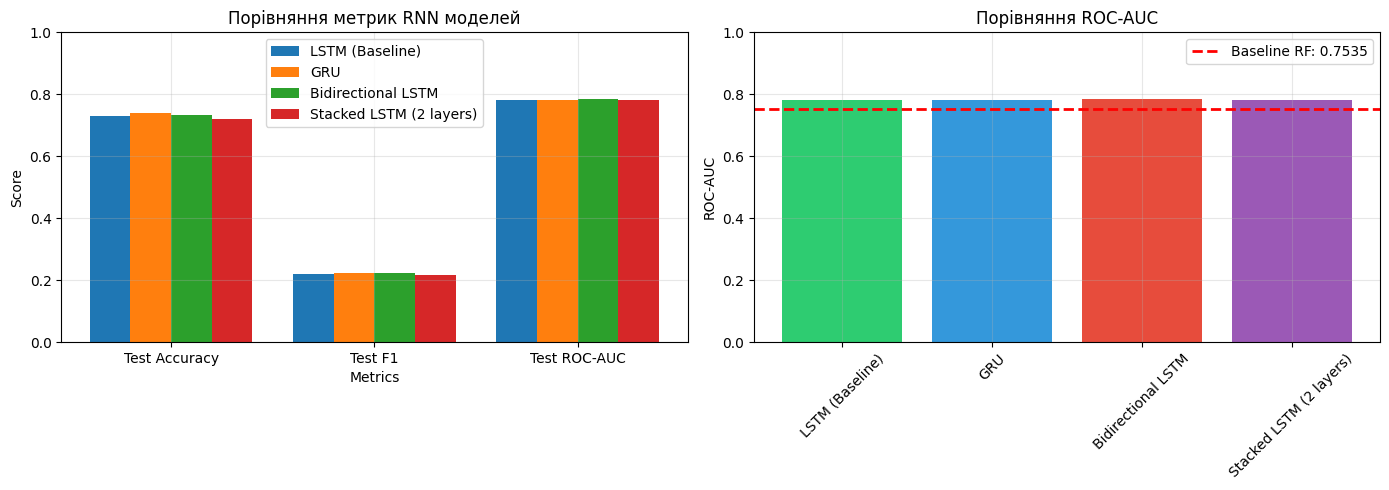

In [8]:
print("Порівняння резкльтатів експерименту")

# Збираємо всі результати
results = [result_baseline, result_gru, result_bidirectional, result_stacked]

# Створюємо DataFrame для порівняння
comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Val AUC': r['best_val_auc'],
        'Test Accuracy': r['test_accuracy'],
        'Test F1': r['test_f1'],
        'Test ROC-AUC': r['test_auc'],
        'Best Epoch': r['best_epoch']
    }
    for r in results
])

print("\n Порівняльна таблиця (RNN моделі):")
display(comparison_df.round(4))

if baseline_loaded:
    print("Порівняння з  BASELINE (RANDOM FOREST)")
    
    baseline_comparison = pd.DataFrame([
        {
            'Model': 'Random Forest (Baseline)',
            'Test Accuracy': baseline_accuracy,
            'Test F1': baseline_f1,
            'Test ROC-AUC': baseline_auc
        }
    ])
    
    for r in results:
        baseline_comparison = pd.concat([baseline_comparison, pd.DataFrame([{
            'Model': r['name'],
            'Test Accuracy': r['test_accuracy'],
            'Test F1': r['test_f1'],
            'Test ROC-AUC': r['test_auc']
        }])], ignore_index=True)
    
    print("\n Порівняння з BASELINE:")
    display(baseline_comparison.round(4))

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot метрик
metrics = ['Test Accuracy', 'Test F1', 'Test ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, row in comparison_df.iterrows():
    values = [row['Test Accuracy'], row['Test F1'], row['Test ROC-AUC']]
    axes[0].bar(x + i*width, values, width, label=row['Model'])

axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Порівняння метрик RNN моделей')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# ROC-AUC порівняння
all_aucs = comparison_df['Test ROC-AUC'].tolist()
all_models = comparison_df['Model'].tolist()
colors_auc = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

bars = axes[1].bar(all_models, all_aucs, color=colors_auc)

# Додаємо лінію baseline
if baseline_loaded:
    axes[1].axhline(y=baseline_auc, color='red', linestyle='--', linewidth=2, 
                    label=f'Baseline RF: {baseline_auc:.4f}')
    axes[1].legend()

axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Порівняння ROC-AUC')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'experiments' / 'comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Аналіз історії тренування


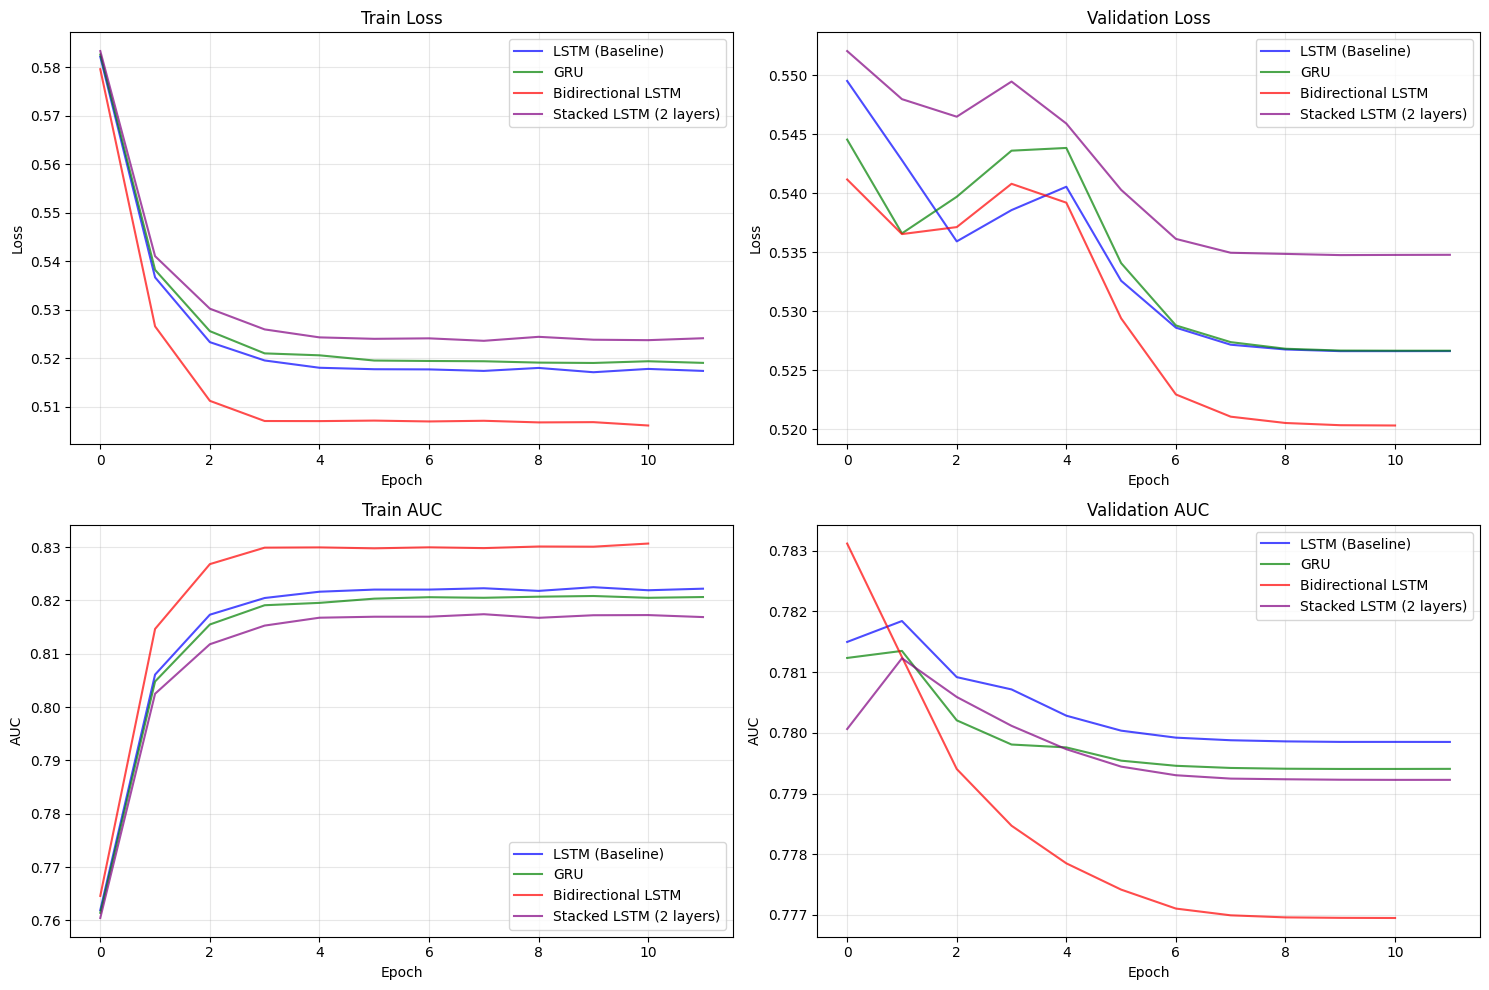

In [9]:
print("Аналіз історії тренування")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

colors = ['blue', 'green', 'red', 'purple']

for i, result in enumerate(results):
    history = result['history']
    axes[0, 0].plot(history.history['loss'], label=result['name'], color=colors[i], alpha=0.7)
    axes[0, 1].plot(history.history['val_loss'], label=result['name'], color=colors[i], alpha=0.7)
    axes[1, 0].plot(history.history['auc'], label=result['name'], color=colors[i], alpha=0.7)
    axes[1, 1].plot(history.history['val_auc'], label=result['name'], color=colors[i], alpha=0.7)

axes[0, 0].set_title('Train Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Train AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Validation AUC')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'experiments' / 'training_history.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
print("Вибір найкращої моделі")

# Знаходимо найкращу модель за ROC-AUC
best_result = max(results, key=lambda x: x['test_auc'])

print(f"\n Найкраща модель: {best_result['name']}")
print(f"\n Її метрики:")
print(f"  Test ROC-AUC:  {best_result['test_auc']:.4f} ({best_result['test_auc']*100:.2f}%)")
print(f"  Test F1-Score: {best_result['test_f1']:.4f} ({best_result['test_f1']*100:.2f}%)")
print(f"  Test Accuracy: {best_result['test_accuracy']:.4f} ({best_result['test_accuracy']*100:.2f}%)")
print(f"  Best Val AUC:  {best_result['best_val_auc']:.4f}")

# Порівняння з baseline LSTM
baseline_auc_lstm = results[0]['test_auc']
improvement = (best_result['test_auc'] - baseline_auc_lstm) / baseline_auc_lstm * 100

print(f"\n Покращення відносно BASELINE LSTM:")
print(f"  ROC-AUC: +{improvement:.1f}%")

if baseline_loaded:
    improvement_vs_rf = (best_result['test_auc'] - baseline_auc) / baseline_auc * 100
    print(f"\n Порівняння з RANDOM FOREST (BASELINE):")
    print(f"  RF ROC-AUC:     {baseline_auc:.4f}")
    print(f"  Best RNN:       {best_result['test_auc']:.4f}")
    print(f"  Покращення:     +{improvement_vs_rf:.1f}%")

Вибір найкращої моделі

 Найкраща модель: Bidirectional LSTM

 Її метрики:
  Test ROC-AUC:  0.7836 (78.36%)
  Test F1-Score: 0.2229 (22.29%)
  Test Accuracy: 0.7341 (73.41%)
  Best Val AUC:  0.7831

 Покращення відносно BASELINE LSTM:
  ROC-AUC: +0.2%

 Порівняння з RANDOM FOREST (BASELINE):
  RF ROC-AUC:     0.7535
  Best RNN:       0.7836
  Покращення:     +4.0%


In [12]:
print("Збереження результатів")

# Зберігаємо порівняльну таблицю
comparison_df.to_csv(MODELS_DIR / 'experiments' / 'comparison_results.csv', index=False)
print(f" Порівняльна таблиця збережена")

# Зберігаємо детальні результати
experiments_results = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_model': best_result['name'],
    'best_model_metrics': {
        'test_auc': float(best_result['test_auc']),
        'test_f1': float(best_result['test_f1']),
        'test_accuracy': float(best_result['test_accuracy'])
    },
    'all_models': [
        {
            'name': r['name'],
            'test_auc': float(r['test_auc']),
            'test_f1': float(r['test_f1']),
            'test_accuracy': float(r['test_accuracy']),
            'best_val_auc': float(r['best_val_auc'])
        }
        for r in results
    ]
}

if baseline_loaded:
    experiments_results['baseline'] = {
        'model': 'Random Forest',
        'test_auc': baseline_auc,
        'test_f1': baseline_f1,
        'test_accuracy': baseline_accuracy
    }
    experiments_results['improvement_vs_baseline'] = float(
        (best_result['test_auc'] - baseline_auc) / baseline_auc * 100
    )

with open(MODELS_DIR / 'experiments' / 'experiments_results.json', 'w', encoding='utf-8') as f:
    json.dump(experiments_results, f, indent=4, default=str)

print(f" Результати експериментів збережено")

Збереження результатів
 Порівняльна таблиця збережена
 Результати експериментів збережено


In [13]:


print(f"""
                    РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТІВ                 
  ТЕСТОВІ МОДЕЛІ:                                            
    • LSTM (Baseline):    AUC = {results[0]['test_auc']:.4f}                             
    • GRU:                AUC = {results[1]['test_auc']:.4f}                             
    • Bidirectional LSTM: AUC = {results[2]['test_auc']:.4f}                             
    • Stacked LSTM:       AUC = {results[3]['test_auc']:.4f}                             
   Найкраща модель : {best_result['name']:<35} 
  ВИСНОВКИ:                                                  
     Експерименти завершено                                 
     Найкраща модель: {best_result['name']}                      
     Покращення відносно LSTM: +{improvement:.1f}%                 
""")

if baseline_loaded:
    improvement_vs_rf = (best_result['test_auc'] - baseline_auc) / baseline_auc * 100
    print(f" Покращення відносно RF: +{improvement_vs_rf:.1f}% ")


# Отримуємо передбачення кращої моделі
y_pred = best_result['y_pred']
y_pred_proba = best_result['y_pred_proba']

# Переконуємось, що це плоскі масиви
y_test_flat = y_test.flatten() if hasattr(y_test, 'flatten') else y_test
y_pred_flat = y_pred.flatten() if hasattr(y_pred, 'flatten') else y_pred

print(f"\n Розмір даних:")
print(f"  y_test: {len(y_test_flat):,}")
print(f"  y_pred: {len(y_pred_flat):,}")

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test_flat, y_pred_flat)

print("\n MATRIX ПОМИЛОК:")
print("                 Передбачено")
print("               Неякісні  Якісні")
print(f"Факт Неякісні   {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"     Якісні     {cm[1,0]:6d}   {cm[1,1]:6d}")

# Classification Report
print("\n CLASSIFICATION REPORT:")
print(classification_report(y_test_flat, y_pred_flat, target_names=['Неякісні (0)', 'Якісні (1)']))

print("\n Аналіз помилок:")

# False Positives: y_test == 0, але y_pred == 1
fp_mask = (y_test_flat == 0) & (y_pred_flat == 1)
false_positives = np.where(fp_mask)[0]  

# False Negatives: y_test == 1, але y_pred == 0
fn_mask = (y_test_flat == 1) & (y_pred_flat == 0)
false_negatives = np.where(fn_mask)[0]  

print(f"  False Positives (хибнопозитивні): {len(false_positives):,} сесій")
print(f"  False Negatives (хибнонегативні): {len(false_negatives):,} сесій")
print(f"  Загальна кількість помилок: {len(false_positives) + len(false_negatives):,}")

# Розподіл передбачень
print(f"\n Розподіл передбачень:")
print(f"  Передбачено як якісні:   {np.sum(y_pred_flat == 1):,} сесій")
print(f"  Передбачено як неякісні: {np.sum(y_pred_flat == 0):,} сесій")
print(f"  Фактично якісних:        {np.sum(y_test_flat == 1):,} сесій")





                    РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТІВ                 
  ТЕСТОВІ МОДЕЛІ:                                            
    • LSTM (Baseline):    AUC = 0.7822                             
    • GRU:                AUC = 0.7816                             
    • Bidirectional LSTM: AUC = 0.7836                             
    • Stacked LSTM:       AUC = 0.7814                             
   Найкраща модель : Bidirectional LSTM                  
  ВИСНОВКИ:                                                  
     Експерименти завершено                                 
     Найкраща модель: Bidirectional LSTM                      
     Покращення відносно LSTM: +0.2%                 

 Покращення відносно RF: +4.0% 

 Розмір даних:
  y_test: 1,387,460
  y_pred: 1,387,460

 MATRIX ПОМИЛОК:
                 Передбачено
               Неякісні  Якісні
Факт Неякісні   965696   345323
     Якісні      23538    52903

 CLASSIFICATION REPORT:
              precision    recall  f1-score   su